In [2]:
 import pandas as pd
df=pd.read_csv("heart2.csv")
print(df.head())
print(df["target"].value_counts())
print(df.info())
print(df.describe())
print(df.isnull())
x=df.drop("target",axis=1)
y=df["target"]
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(
 x,y,test_size = 0.2,random_state =42
)

   age  sex  cp  trestbps  chol  fbs  thalach  exang  oledpeak  ca  target
0   49    0   3       177   150    0       95      0       2.3   0       0
1   56    1   0       124   172    1       86      1       0.5   0       1
2   66    0   3       100   239    0      105      0       1.7   0       0
3   64    0   0       168   222    0       95      1       2.8   0       1
4   60    1   2       153   358    0      147      0       3.2   0       1
1    10
0     5
Name: target, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       15 non-null     int64  
 1   sex       15 non-null     int64  
 2   cp        15 non-null     int64  
 3   trestbps  15 non-null     int64  
 4   chol      15 non-null     int64  
 5   fbs       15 non-null     int64  
 6   thalach   15 non-null     int64  
 7   exang     15 non-null     int64  
 8   oledpeak 

In [3]:
from sklearn.tree import DecisionTreeClassifier
df=DecisionTreeClassifier(random_state=42)
df.fit(x_train,y_train)
pred=df.predict(x_test)
print(pred[ :10])

[1 1 1]


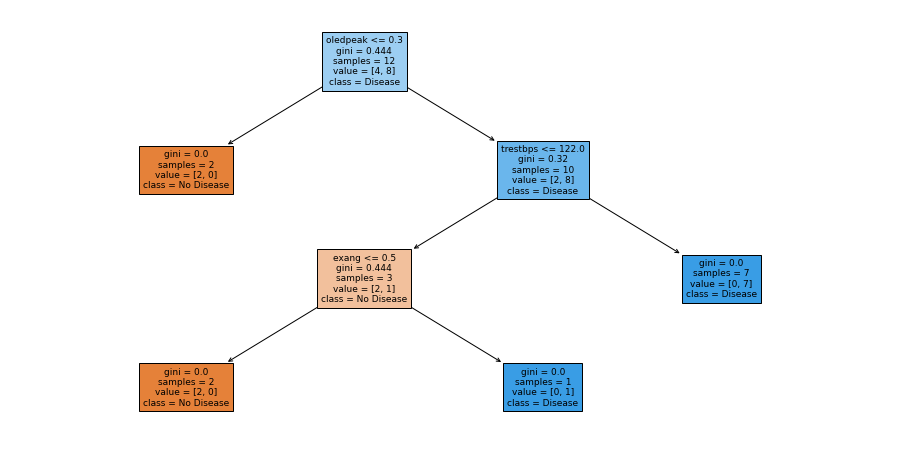

In [10]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(16,8))
plot_tree(df,feature_names=x.columns,
         class_names=["No Disease","Disease"],
         filled=True,max_depth=3,fontsize=9)
plt.show()
    

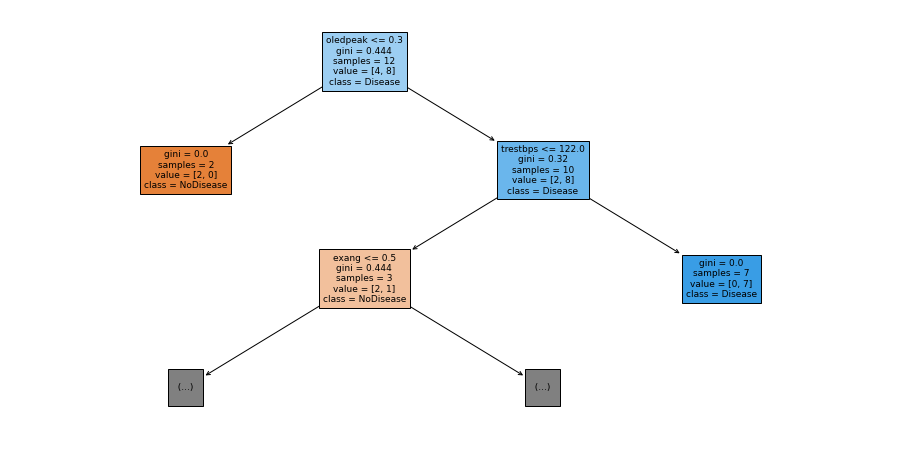

In [4]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(16,8))
plot_tree(df,feature_names=x.columns,
         class_names=["NoDisease","Disease"],
         filled=True,max_depth=2,fontsize=9)
plt.show()

In [6]:
for depth in [2,3,4,5,None]:
    df_d=DecisionTreeClassifier(
    max_depth=depth,random_state=42
    )
    df_d.fit(x_train,y_train)
    train_acc=df_d.score(x_train,y_train)
    test_acc=df_d.score(x_test,y_test)
    print(depth,train_acc,test_acc)

2 0.9166666666666666 0.6666666666666666
3 1.0 0.6666666666666666
4 1.0 0.6666666666666666
5 1.0 0.6666666666666666
None 1.0 0.6666666666666666


In [7]:
for depth in [2,3,4,5,None]:
    df_d=DecisionTreeClassifier(
    max_depth=depth,random_state=42
    )
    df_d.fit(x_train,y_train)
    train_acc=df_d.score(x_train,y_train)
    test_acc=df_d.score(x_test,y_test)
    print("max_depth =",depth,"-> Train acc:", round(train_acc,3), "Test acc:",round(test_acc,3))

max_depth = 2 -> Train acc: 0.917 Test acc: 0.667
max_depth = 3 -> Train acc: 1.0 Test acc: 0.667
max_depth = 4 -> Train acc: 1.0 Test acc: 0.667
max_depth = 5 -> Train acc: 1.0 Test acc: 0.667
max_depth = None -> Train acc: 1.0 Test acc: 0.667


In [9]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(
n_estimators=100,random_state=42
)
rf.fit(x_train,y_train)
pred_rf=rf.predict(x_test)

age         0.176912
chol        0.161287
oledpeak    0.154095
trestbps    0.148168
thalach     0.116003
exang       0.078267
sex         0.062149
cp          0.062040
ca          0.021853
fbs         0.019227
dtype: float64


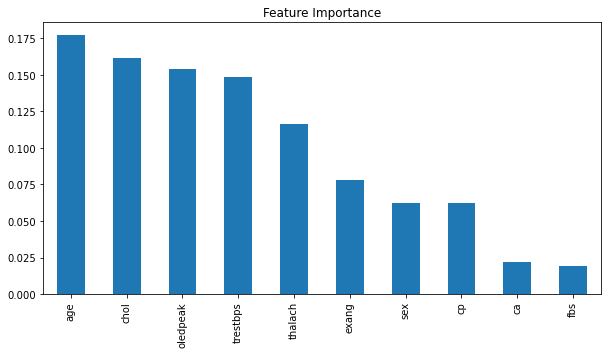

In [15]:
import numpy as np
importances= rf.feature_importances_
feat_imp = pd.Series(importances,index=x.columns).sort_values(ascending = False)
print(feat_imp)
feat_imp.plot(kind="bar",figsize=(10,5))
plt.title("Feature Importance")
plt.show()

In [22]:
for n in [50,100,200]:
    for depth in [3,5,None]:
        rf_t=RandomForestClassifier(
        n_estimators=n,max_depth=depth,random_state=42
        )
        rf_t.fit(x_train,y_train)
        acc=rf_t.score(x_test,y_test)
        print("n_estimators =",n,"->  max_depth =",depth,"  -> Accuracy:",round(acc,3))        

n_estimators = 50 ->  max_depth = 3   -> Accuracy: 0.333
n_estimators = 50 ->  max_depth = 5   -> Accuracy: 0.333
n_estimators = 50 ->  max_depth = None   -> Accuracy: 0.333
n_estimators = 100 ->  max_depth = 3   -> Accuracy: 0.333
n_estimators = 100 ->  max_depth = 5   -> Accuracy: 0.333
n_estimators = 100 ->  max_depth = None   -> Accuracy: 0.333
n_estimators = 200 ->  max_depth = 3   -> Accuracy: 0.333
n_estimators = 200 ->  max_depth = 5   -> Accuracy: 0.333
n_estimators = 200 ->  max_depth = None   -> Accuracy: 0.333


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
models={
    "Logistic Regression":LogisticRegression(max_iter=1000),
    "KNN(k=5)":KNeighborsClassifier(n_neighbors=5),
    "Decision Tree":DecisionTreeClassifier(random_state=42),
    "Random Forest":RandomForestClassifier(n_estimators=100,random_state=42),
}
results=[]
for name,m in models.items():
    m.fit(x_train,y_train)
    p=m.predict(x_test)
    results.append([
        name,
        accuracy_score(y_test,p),
        precision_score(y_test,p),
        recall_score(y_test,p),
        f1_score(y_test,p)
    ])
    comparision_df=pd.DataFrame(results,
                                columns=["Model","Accuracy","precision","Recall","F1 score"])
    print(comparision_df)

                 Model  Accuracy  precision  Recall  F1 score
0  Logistic Regression  0.333333        0.5     0.5       0.5
                 Model  Accuracy  precision  Recall  F1 score
0  Logistic Regression  0.333333        0.5     0.5       0.5
1             KNN(k=5)  0.333333        0.5     0.5       0.5
                 Model  Accuracy  precision  Recall  F1 score
0  Logistic Regression  0.333333   0.500000     0.5       0.5
1             KNN(k=5)  0.333333   0.500000     0.5       0.5
2        Decision Tree  0.666667   0.666667     1.0       0.8
                 Model  Accuracy  precision  Recall  F1 score
0  Logistic Regression  0.333333   0.500000     0.5       0.5
1             KNN(k=5)  0.333333   0.500000     0.5       0.5
2        Decision Tree  0.666667   0.666667     1.0       0.8
3        Random Forest  0.333333   0.500000     0.5       0.5
